Initial Hypothesis: ['0', '0', '0', '0']

Positive Example - Evaluating: ['Sunny', 'Hot', 'High', 'Weak', 'Yes']
Updated Hypothesis: ['Sunny', 'Hot', 'High', 'Weak']

Positive Example - Evaluating: ['Sunny', 'Mild', 'High', 'Strong', 'Yes']
Updated Hypothesis: ['Sunny', '?', 'High', '?']

Negative Example - Skipped: ['Rainy', 'Cold', 'Low', 'Weak', 'No']
Positive Example - Evaluating: ['Sunny', 'Mild', 'Normal', 'Strong', 'Yes']
Updated Hypothesis: ['Sunny', '?', '?', '?']

Negative Example - Skipped: ['Rainy', 'Cold', 'High', 'Weak', 'No']
Positive Example - Evaluating: ['Sunny', 'Hot', 'Normal', 'Strong', 'Yes']
Updated Hypothesis: ['Sunny', '?', '?', '?']

Final Hypothesis: ['Sunny', '?', '?', '?']


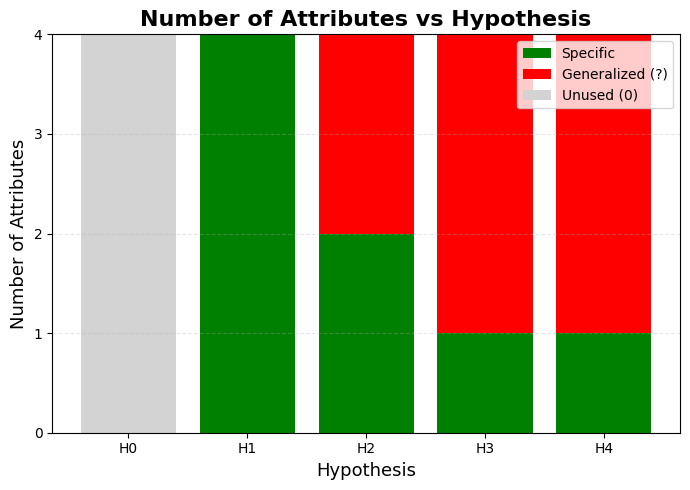

In [3]:
# Find-S Algorithm

import matplotlib.pyplot as plt

dataset = [
    ["Sunny", "Hot", "High", "Weak", "Yes"],
    ["Sunny", "Mild", "High", "Strong", "Yes"],
    ["Rainy", "Cold", "Low", "Weak", "No"],
    ["Sunny", "Mild", "Normal", "Strong", "Yes"],
    ["Rainy", "Cold", "High", "Weak", "No"],
    ["Sunny", "Hot", "Normal", "Strong", "Yes"]
]

attributes = dataset[0][:-1]

hypothesis = ["0"] * len(attributes)

history = []

print("Initial Hypothesis:", hypothesis)
print()

for example in dataset:

    example_attributes = example[:-1]
    target = example[-1]

    if target == "No":

        print("Negative Example - Skipped:", example)
        continue

    print("Positive Example - Evaluating:", example)

    if hypothesis[0] == "0":

        hypothesis = example_attributes.copy()

    else:

        for i in range(len(hypothesis)):

            if hypothesis[i] != example_attributes[i]:

                hypothesis[i] = "?"

    history.append(hypothesis.copy())

    print("Updated Hypothesis:", hypothesis)
    print()

print("Final Hypothesis:", hypothesis)

all_hypotheses = [["0"] * len(attributes)] + history

hypothesis_labels = [
    f"H{i}" for i in range(len(all_hypotheses))
]

unused_counts = []
specific_counts = []
generalized_counts = []

for hypothesis in all_hypotheses:

    unused = hypothesis.count("0")
    generalized = hypothesis.count("?")
    specific = len(hypothesis) - unused - generalized

    unused_counts.append(unused)
    specific_counts.append(specific)
    generalized_counts.append(generalized)

plt.figure(figsize=(7, 5))

plt.bar(
    hypothesis_labels,
    specific_counts,
    color="green",
    label="Specific"
)

plt.bar(
    hypothesis_labels,
    generalized_counts,
    bottom=specific_counts,
    color="red",
    label="Generalized (?)"
)

bottom_unused = [
    specific_counts[i] + generalized_counts[i]
    for i in range(len(hypothesis_labels))
]

plt.bar(
    hypothesis_labels,
    unused_counts,
    bottom=bottom_unused,
    color="lightgray",
    label="Unused (0)"
)

plt.title(
    "Number of Attributes vs Hypothesis",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Hypothesis",
    fontsize=13
)

plt.ylabel(
    "Number of Attributes",
    fontsize=13
)

plt.legend()

plt.yticks(range(0, len(attributes) + 1))

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()
